# 주제 : 데이터 분석으로 심부전증을 예방할 수 있을까?

## 데이터 소개
- 이번 주제는 Heart Failure Prediction 데이터셋을 사용합니다.

- 다음 1개의 csv 파일을 사용합니다.
heart_failure_clinical_records_dataset.csv

- 각 파일의 컬럼은 아래와 같습니다.   
age: 환자의 나이   
anaemia: 환자의 빈혈증 여부 (0: 정상, 1: 빈혈)   
creatinine_phosphokinase: 크레아틴키나제 검사 결과   
diabetes: 당뇨병 여부 (0: 정상, 1: 당뇨)   
ejection_fraction: 박출계수 (%)   
high_blood_pressure: 고혈압 여부 (0: 정상, 1: 고혈압)   
platelets: 혈소판 수 (kiloplatelets/mL)   
serum_creatinine: 혈중 크레아틴 레벨 (mg/dL)   
serum_sodium: 혈중 나트륨 레벨 (mEq/L)   
sex: 성별 (0: 여성, 1: 남성)   
smoking: 흡연 여부 (0: 비흡연, 1: 흡연)   
time: 관찰 기간 (일)   
DEATH_EVENT: 사망 여부 (0: 생존, 1: 사망)



데이터 출처: https://www.kaggle.com/andrewmvd/heart-failure-clinical-data

## 최종 목표
- 의료 데이터와 그 분석에 대한 이해
- Colab 및 Pandas 라이브러리 사용법 이해
- 데이터 시각화를 통한 인사이트 습득 방법의 이해
- Scikit-learn 기반의 모델 학습 방법 습득
- Classification 모델의 학습과 평가 방법 이해

출제자 : 신제용 강사

## Step 0. 의료 데이터셋에 대하여
- 의료 데이터의 수집
- 의료 데이터 분석의 현재
- Accuracy, Precision, 그리고 Recall


## Step 1. 데이터셋 준비하기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 문제 1. Colab Notebook에 Kaggle API 세팅하기

In [3]:
import os

In [4]:
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기
os.environ['KAGGLE_USERNAME'] = 'fastcampuskim'
os.environ['KAGGLE_KEY'] = 'c939a1e37f5ca93b6406a66fc8bb08e5'

### 문제 2. 데이터 다운로드 및 압축 해제하기

In [5]:
# Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기 (!kaggle ~)
# Linux 명령어로 압축 해제하기
!kaggle datasets download -d andrewmvd/heart-failure-clinical-data
!unzip '*.zip'

!ls

  0% 0.00/3.97k [00:00<?, ?B/s]
100% 3.97k/3.97k [00:00<00:00, 1.92MB/s]
Archive:  heart-failure-clinical-data.zip
  inflating: heart_failure_clinical_records_dataset.csv  
heart-failure-clinical-data.zip		    sample_data
heart_failure_clinical_records_dataset.csv


### 문제 3. Pandas 라이브러리로 csv파일 읽어들이기

In [6]:
# pd.read_csv()로 csv파일 읽어들이기
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Step 2. EDA 및 데이터 기초 통계 분석

### 문제 4. 데이터프레임의 각 컬럼 분석하기

In [7]:
df.info()
# 범주형 : anaemia, diabetes, high_blood_pressure, sex, smoking, DEATH_EVENT

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [8]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


### 문제 5. 수치형 데이터의 히스토그램 그리기

<Axes: xlabel='age', ylabel='Count'>

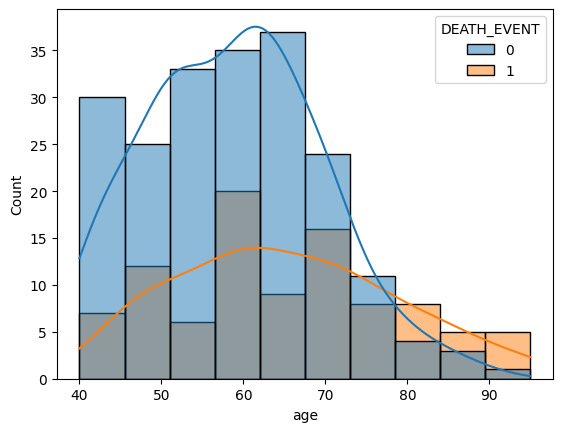

In [9]:
sns.histplot(x='age', data=df, hue='DEATH_EVENT', kde=True)
# 나이가 많을수록 심부전증으로 사망한 경우가 많음

<Axes: xlabel='creatinine_phosphokinase', ylabel='Count'>

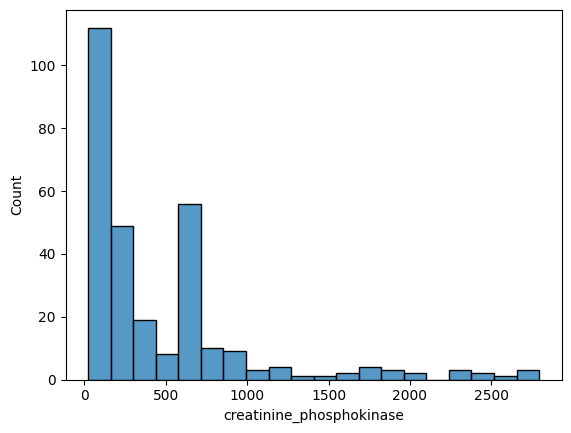

In [10]:
sns.histplot(data=df.loc[df['creatinine_phosphokinase'] < 3000, 'creatinine_phosphokinase'])
# 대부분 크레아틴키나제 수치가 낮은 경우가 많음, 왼쪽으로 쏠려있는 분포 

<Axes: xlabel='ejection_fraction', ylabel='Count'>

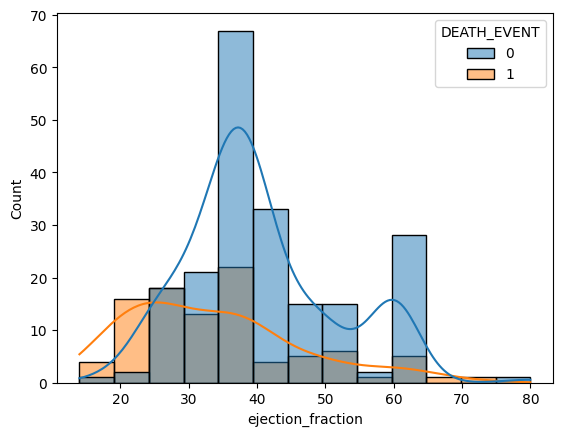

In [11]:
sns.histplot(x='ejection_fraction', data=df, bins=13, hue='DEATH_EVENT', kde=True)
# 박출계수가 낮은 경우 심부전증에 의한 사망이 많음.

<Axes: xlabel='platelets', ylabel='Count'>

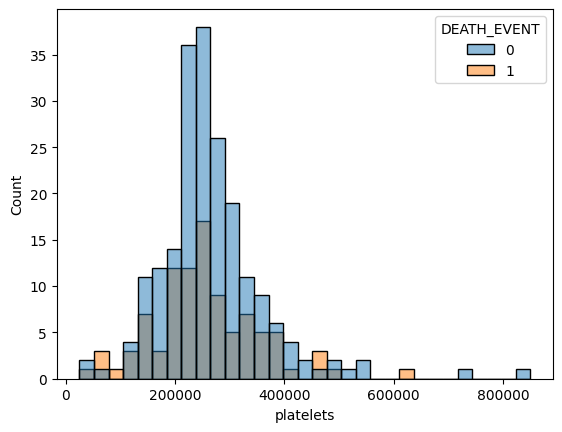

In [12]:
sns.histplot(x='platelets', data=df, hue='DEATH_EVENT')
# 큰 차이 없는 것 같음

<Axes: xlabel='time', ylabel='Count'>

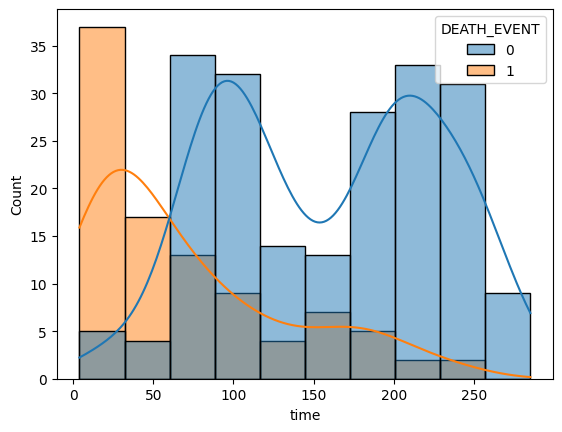

In [13]:
sns.histplot(x='time', data=df, hue='DEATH_EVENT', kde=True)
# 관찰기간이 짧을수록 사망한 경우가 많음. < 당연함..

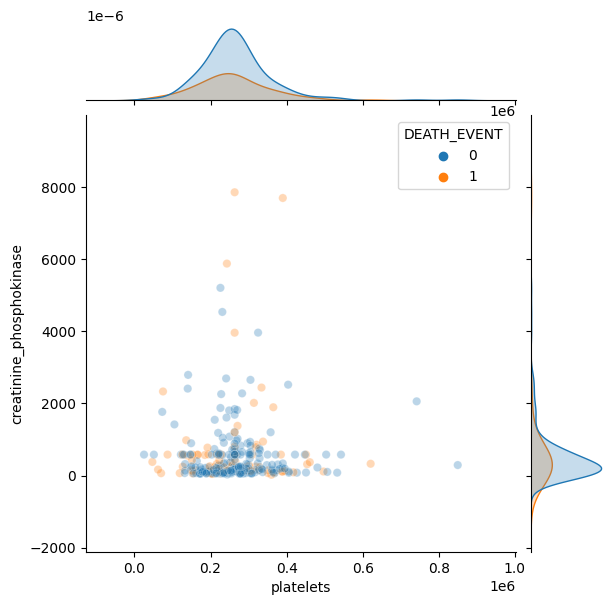

In [14]:
sns.jointplot(x='platelets', y='creatinine_phosphokinase', hue="DEATH_EVENT", data=df, alpha=0.3)
# 둘 사이에 상관관계가 없어보임

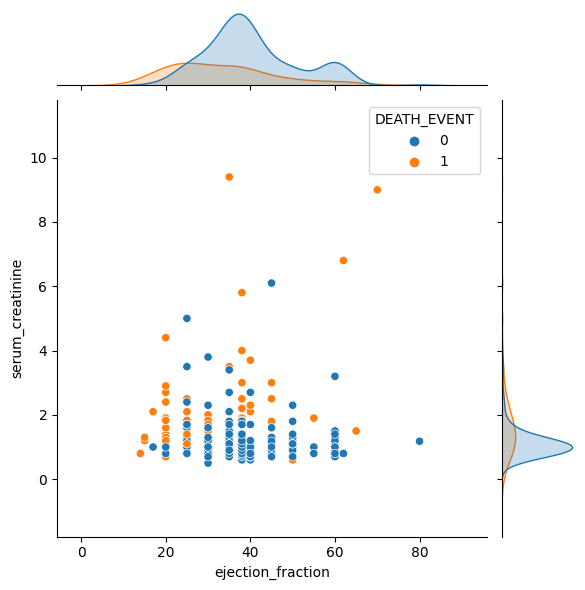

In [15]:
sns.jointplot(x='ejection_fraction', y='serum_creatinine', data=df, hue='DEATH_EVENT')
# 심부전증으로 사망한 경우가 그렇지 않은 경우보다 혈중 크레아틴 레벨이 높음

### 문제 6. Boxplot 계열을 이용하여 범주별 통계 확인하기

<Axes: xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

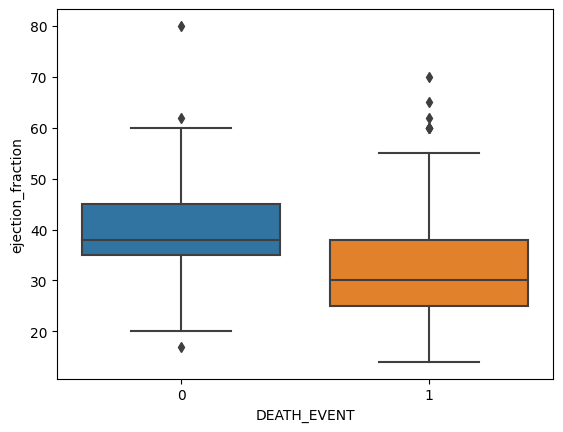

In [16]:
sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=df)
# 사망한 경우의 박출계수가 더 낮음

<Axes: xlabel='smoking', ylabel='ejection_fraction'>

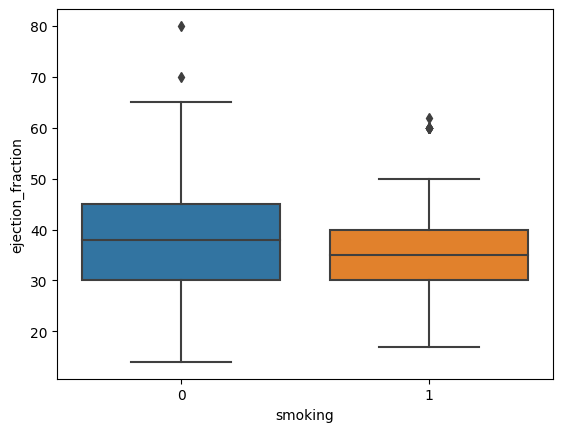

In [17]:
sns.boxplot(x='smoking', y='ejection_fraction', data=df)
# 큰 차이가 없어보임. (흡연자인 경우의 분포가 더 좁음)

<Axes: xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

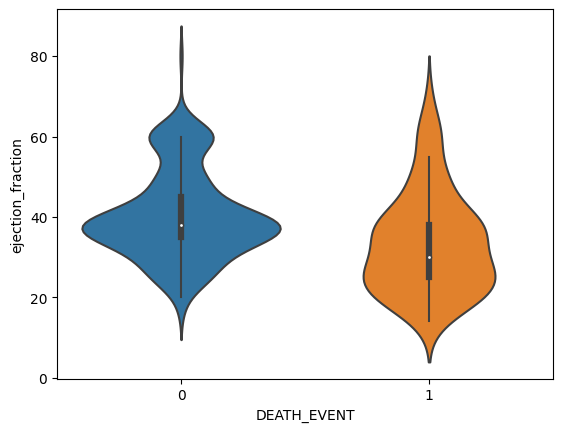

In [18]:
sns.violinplot(x='DEATH_EVENT', y='ejection_fraction', data=df)
# boxplot에 비해 조금 더 데이터의 분포를 자세하게 볼 수 있음

<Axes: xlabel='DEATH_EVENT', ylabel='platelets'>

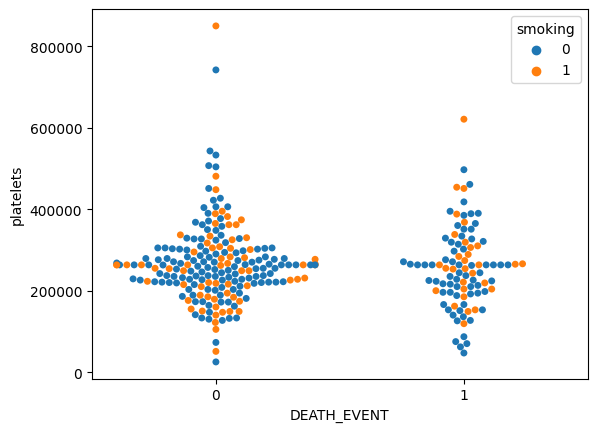

In [19]:
sns.swarmplot(x='DEATH_EVENT', y='platelets', hue='smoking', data=df)
# 세 변수간에 큰 상관성이 없어보임

## Step 3. 모델 학습을 위한 데이터 전처리

### 문제 7. StandardScaler를 이용하여 데이터 전처리하기

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
# 수치형, 범주형 입력 데이터, 출력데이터 구분하기
X_num = df[['age','creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium','time']]
X_cat = df[['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']]
y = df['DEATH_EVENT']

In [22]:
# 수치형 데이터 전처리 및 통합
scaler = StandardScaler() # 표준화(평균 0, 표준편차 1)
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)
X_scaled = pd.DataFrame(data=X_scaled, index=X_num.index, columns=X_num.columns)
X = pd.concat([X_scaled, X_cat], axis=1) # 범주형 변수와 통합

In [23]:
X

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia,diabetes,high_blood_pressure,sex,smoking
0,1.192945,0.000166,-1.530560,1.681648e-02,0.490057,-1.504036,-1.629502,0,0,1,1,0
1,-0.491279,7.514640,-0.007077,7.535660e-09,-0.284552,-0.141976,-1.603691,0,0,0,1,0
2,0.350833,-0.449939,-1.530560,-1.038073e+00,-0.090900,-1.731046,-1.590785,0,0,0,1,1
3,-0.912335,-0.486071,-1.530560,-5.464741e-01,0.490057,0.085034,-1.590785,1,0,0,1,0
4,0.350833,-0.435486,-1.530560,6.517986e-01,1.264666,-4.682176,-1.577879,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.537688,-0.007077,-1.109765e+00,-0.284552,1.447094,1.803451,0,1,1,1,1
295,-0.491279,1.278215,-0.007077,6.802472e-02,-0.187726,0.539054,1.816357,0,0,0,0,0
296,-1.333392,1.525979,1.854958,4.902082e+00,-0.575031,0.312044,1.906697,0,1,0,0,0
297,-1.333392,1.890398,-0.007077,-1.263389e+00,0.005926,0.766064,1.932509,0,0,0,1,1


### 문제 8. 학습데이터와 테스트데이터 분리하기

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

## Step 4. Classification 모델 학습하기

### 문제 9. Logistic Regression 모델 생성/학습하기

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### 문제 10. 모델 학습 결과 평가하기

In [28]:
from sklearn.metrics import classification_report

In [29]:
pred = model_lr.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89        64
           1       0.76      0.62      0.68        26

    accuracy                           0.83        90
   macro avg       0.81      0.77      0.78        90
weighted avg       0.83      0.83      0.83        90



### 문제 11. XGBoost 모델 생성/학습하기

In [30]:
from xgboost import XGBClassifier

In [31]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

### 문제 12. 모델 학습 결과 평가하기

In [32]:
pred = model_xgb.predict(X_test)
print(classification_report(y_test, pred))
# f1-score 기준 LR보다 성능 좋음

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        64
           1       0.79      0.88      0.84        26

    accuracy                           0.90        90
   macro avg       0.87      0.90      0.88        90
weighted avg       0.91      0.90      0.90        90



### 문제 13. 특징의 중요도 확인하기

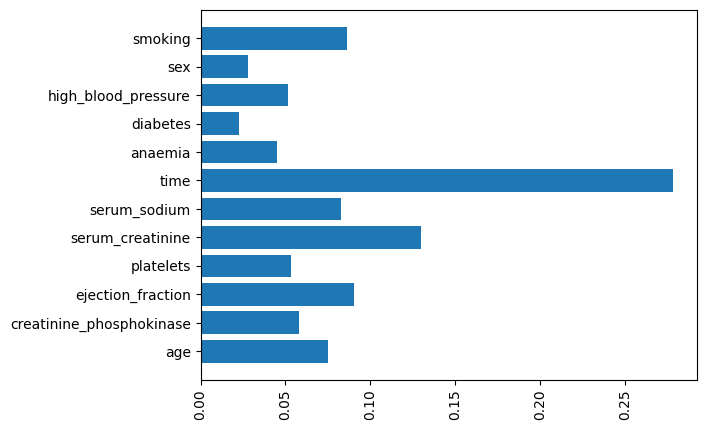

In [33]:
plt.barh(X.columns, model_xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()
# time, serum_creatinine, ejction_fraction 순으로 중요도가 높음

In [34]:
df[['time','DEATH_EVENT']].corr()

,time,DEATH_EVENT
time,1.000000,-0.526964
DEATH_EVENT,-0.526964,1.000000


In [35]:
df[['serum_creatinine','DEATH_EVENT']].corr()

,serum_creatinine,DEATH_EVENT
serum_creatinine,1.000000,0.294278
DEATH_EVENT,0.294278,1.000000


## Step5 모델 학습 결과 심화 분석하기

### 문제 14. Precision-Recall 커브 확인하기

- 불균형한 데이터 셋을 가졌을 때 핵심 성능평가 방법
- 1에서 시작해서 점차 줄어드는 형태를 보인다.

In [36]:
from sklearn.metrics import precision_recall_curve

In [37]:
pr_logistic,rc_logistic, pr_rc_thre_logistic = precision_recall_curve(y_true=y_test, probas_pred=model_lr.predict_proba(X_test)[:,1])
pr_xgb,rc_xgb, pr_rc_thre_xgb = precision_recall_curve(y_true=y_test, probas_pred=model_xgb.predict_proba(X_test)[:,1])

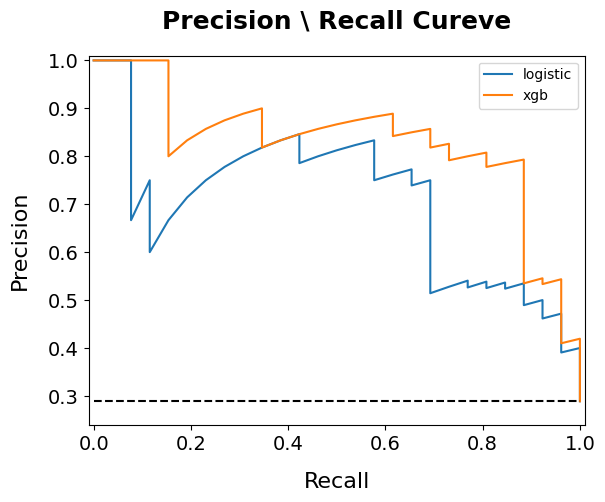

In [38]:
plt.plot(rc_logistic,pr_logistic)
plt.plot(rc_xgb,pr_xgb)

base_rate = y_test.mean()
plt.plot([0,1],[base_rate,base_rate],'k--')

plt.title('Precision \ Recall Cureve',fontsize=18,fontweight="bold",y=1.05)
plt.xlabel('Recall',fontsize=16,labelpad=13)
plt.ylabel('Precision',fontsize=16,labelpad=13,)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(-0.01,1.01)
plt.ylim(base_rate-0.05,1.01)
plt.legend(['logistic','xgb'])

plt.show()

### 문제 15. ROC 커브 확인하기

- 이진분류시스템에 대한 성능 평가 기법
- X축 : False Positive Rate (FP/정답이 Negative인 수) = Negative 중 잘못 예측한 비율 
- y축 : True Positive Rate (TP/정답이 Positive인 수) = Positive 중 잘 예측한 비율
- Positive로 예측한 값들 중 실제로 Positive인 경우가 실제로 Negative인 경우보다 높아야 AUC가 높게 나옴.
- 곡선이 더 굽어질수록(1에가까울수록) AUC가 널

In [39]:
from sklearn.metrics import roc_curve

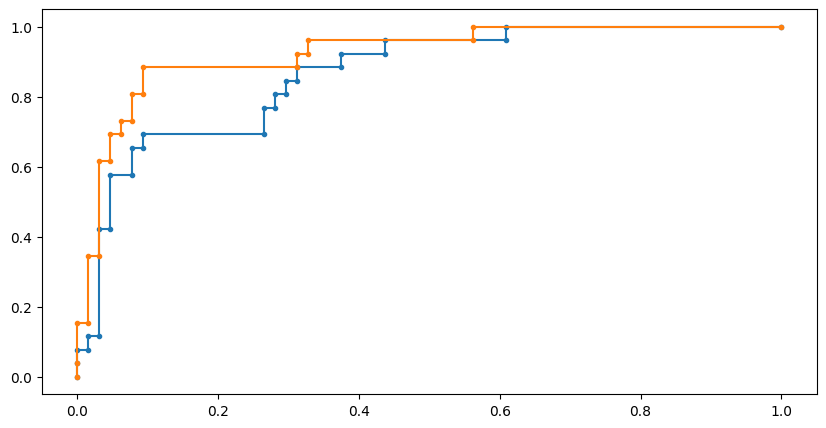

In [41]:
lr_probs = model_lr.predict_proba(X_test)[:,1]
xgb_probs = model_xgb.predict_proba(X_test)[:,1]
fpr1, tpr1, thresholds1 = roc_curve(y_test, lr_probs)
fpr2, tpr2, thresholds2 = roc_curve(y_test, xgb_probs)
plt.figure(figsize=(10,5))
plt.plot(fpr1, tpr1, marker='.')
plt.plot(fpr2, tpr2, marker='.')

plt.show()